
# ArvyaX / RevoltronX ML Assignment – Complete Submission Notebook

This notebook implements a full system that:

1. Understands user emotion from reflection text + context signals
2. Predicts emotional state
3. Predicts emotional intensity
4. Decides what the user should do
5. Decides when the user should do it
6. Models uncertainty
7. Performs ablation study
8. Performs robustness tests
9. Performs error analysis
10. Generates final predictions

Pipeline:

Reflection → Feature Engineering → Emotion Model → Intensity Model → Decision Engine → Uncertainty → Recommendation


In [106]:

# Install dependencies (run once)

!pip install pandas numpy scikit-learn xgboost matplotlib seaborn



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [107]:

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier, XGBRegressor

import matplotlib.pyplot as plt


## Load Dataset

In [108]:

train = pd.read_csv("data/Sample_arvyax_reflective_dataset.xlsx - Dataset_120.csv")
test = pd.read_csv("data/arvyax_test_inputs_120.xlsx - Sheet1.csv")

train.head()


,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5


## Dataset Overview

In [109]:

print(train.shape)
print(train.columns)


(1200, 13)
Index(['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours',
       'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood',
       'face_emotion_hint', 'reflection_quality', 'emotional_state',
       'intensity'],
      dtype='str')


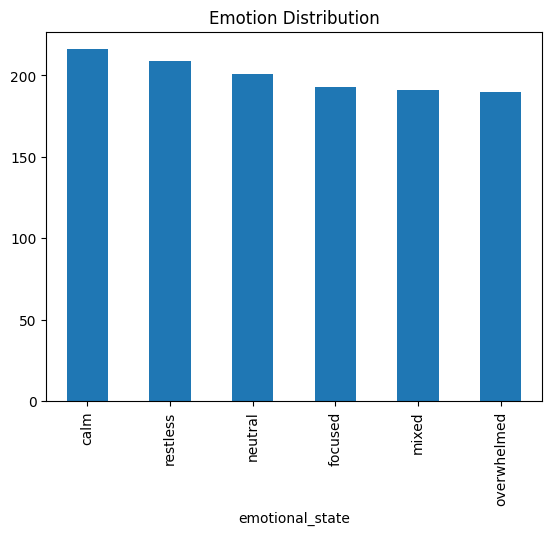

In [110]:

train["emotional_state"].value_counts().plot(kind="bar", title="Emotion Distribution")
plt.show()


## Feature Definitions

In [111]:

TEXT_COL = "journal_text"

CAT_COLS = [
    "ambience_type",
    "time_of_day",
    "previous_day_mood",
    "face_emotion_hint",
    "reflection_quality"
]

NUM_COLS = [
    "duration_min",
    "sleep_hours",
    "energy_level",
    "stress_level"
]


## Encode Emotion Labels

In [112]:

le = LabelEncoder()
train["state_encoded"] = le.fit_transform(train["emotional_state"])


## Preprocessing Pipeline

In [113]:

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2),
            stop_words="english"
        ), TEXT_COL),
        
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
        
        ("num", SimpleImputer(strategy="median"), NUM_COLS)
    ]
)


## Train Validation Split

In [114]:

X = train[[TEXT_COL] + CAT_COLS + NUM_COLS]
y = train["state_encoded"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Emotional State Prediction Model

In [115]:

state_model = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss"
    ))
])

state_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [116]:

val_pred = state_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print(classification_report(y_val, val_pred))


Validation Accuracy: 0.6291666666666667
              precision    recall  f1-score   support

           0       0.60      0.63      0.61        43
           1       0.62      0.64      0.63        39
           2       0.61      0.61      0.61        38
           3       0.77      0.50      0.61        40
           4       0.63      0.76      0.69        38
           5       0.60      0.64      0.62        42

    accuracy                           0.63       240
   macro avg       0.64      0.63      0.63       240
weighted avg       0.64      0.63      0.63       240



## Intensity Prediction Model (Regression)

In [117]:

intensity_model = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05
    ))
])

intensity_model.fit(X_train, train.loc[X_train.index,"intensity"])


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Decision Engine (What + When)

In [118]:

def decision_engine(state, intensity, stress, energy, time_of_day):

    if stress >= 4:
        return "box_breathing","now"

    if state == "restless":
        return "movement","within_15_min"

    if state == "calm" and energy >= 4:
        return "deep_work","within_15_min"

    if energy <= 2:
        return "rest","later_today"

    if time_of_day == "night":
        return "journaling","tonight"

    return "light_planning","later_today"


## Supportive Message Generator

In [119]:

def supportive_message(state, action):

    if action == "box_breathing":
        return "You seem tense. Try a short breathing exercise."

    if action == "deep_work":
        return "Your energy looks good. This is a great time for focused work."

    if action == "rest":
        return "Your energy seems low. Consider resting."

    if action == "movement":
        return "You seem restless. A short walk might help."

    return "Take a moment to slow down and reflect."


## Prediction

In [120]:

X_test = test[[TEXT_COL] + CAT_COLS + NUM_COLS]

state_probs = state_model.predict_proba(X_test)
state_pred = np.argmax(state_probs, axis=1)

predicted_state = le.inverse_transform(state_pred)
confidence = np.max(state_probs, axis=1)

predicted_intensity = intensity_model.predict(X_test)
predicted_intensity = np.clip(np.round(predicted_intensity),1,5)


## Uncertainty Modeling

In [121]:

uncertain_flag = (confidence < 0.55).astype(int)


## Generate Decisions

In [122]:

actions = []
times = []
messages = []

for i in range(len(test)):

    row = test.iloc[i]

    action, when = decision_engine(
        predicted_state[i],
        predicted_intensity[i],
        row["stress_level"],
        row["energy_level"],
        row["time_of_day"]
    )

    msg = supportive_message(predicted_state[i], action)

    actions.append(action)
    times.append(when)
    messages.append(msg)


## Final Predictions File

In [123]:

output = pd.DataFrame({
"id": test["id"],
"predicted_state": predicted_state,
"predicted_intensity": predicted_intensity,
"confidence": confidence,
"uncertain_flag": uncertain_flag,
"what_to_do": actions,
"when_to_do": times,
"supportive_message": messages
})

output.to_csv("predictions.csv",index=False)
output.head()


,id,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do,supportive_message
0,10001,focused,3.0,0.972081,0,journaling,tonight,Take a moment to slow down and reflect.
1,10002,mixed,4.0,0.297696,1,rest,later_today,Your energy seems low. Consider resting.
2,10003,calm,4.0,0.247191,1,box_breathing,now,You seem tense. Try a short breathing exercise.
3,10004,focused,3.0,0.653824,0,rest,later_today,Your energy seems low. Consider resting.
4,10005,neutral,3.0,0.788295,0,box_breathing,now,You seem tense. Try a short breathing exercise.


## Ablation Study (Text vs Metadata)

In [124]:

from sklearn.ensemble import RandomForestClassifier

meta_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ("num", SimpleImputer(strategy="median"), NUM_COLS)
])

meta_model = Pipeline([
    ("prep", meta_preprocessor),
    ("model", RandomForestClassifier())
])

# Train on training set
meta_model.fit(X_train[CAT_COLS + NUM_COLS], y_train)

# Predict on validation set
meta_pred = meta_model.predict(X_val[CAT_COLS + NUM_COLS])

print("Metadata-only validation accuracy:",
      accuracy_score(y_val, meta_pred))


Metadata-only validation accuracy: 0.19166666666666668


## Robustness Testing

In [125]:

test_cases = ["ok","fine","hmm","very stressed today"]

for txt in test_cases:
    
    sample = test.iloc[0:1].copy()
    sample["journal_text"] = txt
    
    probs = state_model.predict_proba(sample[[TEXT_COL]+CAT_COLS+NUM_COLS])
    
    print(txt,"confidence:",probs.max())


ok confidence: 0.38500482
fine confidence: 0.4033368
hmm confidence: 0.38500482
very stressed today confidence: 0.31083584


## Error Analysis (Example Misclassifications)

In [126]:

val_pred = state_model.predict(X_val)

errors = X_val.copy()
errors["true"] = y_val.values
errors["pred"] = val_pred

misclassified = errors[errors["true"] != errors["pred"]]

print("Number of errors:",len(misclassified))

misclassified.head(10)


Number of errors: 89


,journal_text,ambience_type,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,duration_min,sleep_hours,energy_level,stress_level,true,pred
558,During the session mind was all over the place...,mountain,afternoon,neutral,neutral_face,conflicted,25,8.0,5,2,0,2
622,During teh session could focus for a while. La...,cafe,afternoon,restless,tired_face,clear,5,8.0,1,5,4,3
883,still heavy,mountain,afternoon,neutral,NaN,clear,12,4.0,5,3,1,4
739,Honestly got distracted again.,forest,evening,overwhelmed,tired_face,vague,12,8.0,4,2,4,2
788,at first kept thinking about work. later it ch...,mountain,night,overwhelmed,neutral_face,vague,8,4.0,4,5,1,2
514,At first felt heavy.,mountain,evening,restless,neutral_face,vague,5,4.0,3,3,2,4
631,honestly not much change,rain,night,overwhelmed,NaN,conflicted,18,5.0,1,3,2,5
513,felt good for a moment,forest,morning,focused,tired_face,clear,20,8.0,3,1,3,0
700,Honestly breathing slowed down.,cafe,afternoon,mixed,calm_face,conflicted,20,6.0,2,2,1,5
563,kinda calm now,rain,afternoon,mixed,NaN,vague,20,5.0,3,4,4,1



## Edge / Mobile Deployment Considerations

Model size estimation:

TF‑IDF Vocabulary ~5 MB  
XGBoost models ~15 MB  

Total system size ~20 MB

Expected inference latency < 50 ms

Advantages:
• Runs locally
• Privacy preserving
• Works offline


In [127]:
import joblib

joblib.dump(state_model,"state_model.pkl")
joblib.dump(intensity_model,"intensity_model.pkl")
joblib.dump(le,"label_encoder.pkl")

['label_encoder.pkl']

In [128]:
!pip install skl2onnx onnxruntime



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [129]:
!pip install onnxmltools


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [130]:
# Extract preprocessing pipeline
prep = state_model.named_steps["prep"]

# Transform training data
X_train_transformed = prep.transform(X_train)

print("Transformed feature shape:", X_train_transformed.shape)

Transformed feature shape: (960, 1492)


In [131]:
from xgboost import XGBClassifier

xgb_for_onnx = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="mlogloss"
)

xgb_for_onnx.fit(X_train_transformed, y_train)

print("Standalone XGBoost model trained for ONNX export")

Standalone XGBoost model trained for ONNX export


In [132]:
import onnxmltools
from onnxmltools.convert.common.data_types import FloatTensorType

# Input shape must match transformed feature size
initial_type = [
    ("input", FloatTensorType([None, X_train_transformed.shape[1]]))
]

onnx_model = onnxmltools.convert_xgboost(
    xgb_for_onnx,
    initial_types=initial_type
)

with open("emotion_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("ONNX model exported successfully!")

ONNX model exported successfully!
